## NLP Course Graded Project : Neural networks to classify the emotions in tweets, ranging from "traditional" deep learning to state-of-the-art Transformers.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import tf_keras as keras
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix


## 1. Dataset Loading and Splitting the set

In [3]:
# Load train and test sets

train_df = pd.read_csv('/content/drive/MyDrive/project_NLP/dataset/dataset/train.txt', sep=';', names=['text', 'label'])
test_df = pd.read_csv('/content/drive/MyDrive/project_NLP/dataset/dataset/test.txt', sep=';', names=['text', 'label'])

In [4]:
# Splitting the training data into 80% for training 20% for validation
# 'random_state' ensures we get the same split every time we run the code
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

print(f"New Training size: {len(train_df)}")
print(f"Internal Validation size: {len(val_df)}")

New Training size: 12800
Internal Validation size: 3200


In [5]:
print(train_df['label'].value_counts())

label
joy         4341
sadness     3720
anger       1732
fear        1540
love        1008
surprise     459
Name: count, dtype: int64


In [6]:
print(test_df['label'].value_counts())

label
joy         695
sadness     581
anger       275
fear        224
love        159
surprise     66
Name: count, dtype: int64


In [7]:
print(val_df['label'].value_counts())

label
joy         1021
sadness      946
anger        427
fear         397
love         296
surprise     113
Name: count, dtype: int64


## 2. Text Preprocessing : Basic Cleaning, Tokenization, Stopword Removal & Lemmatization

In [9]:
# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def advanced_clean_text(text):
    # 1. Basic Cleaning
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)

    # 2. Tokenization
    tokens = text.split()

    # 3. Stopword Removal & Lemmatization
    clean_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    # Join back into a string (most vectorizers prefer a string)
    return " ".join(clean_tokens)

# Apply to your dataframes
train_df['clean_text'] = train_df['text'].apply(advanced_clean_text)
val_df['clean_text'] = val_df['text'].apply(advanced_clean_text)
test_df['clean_text'] = test_df['text'].apply(advanced_clean_text)

print(train_df[['text', 'clean_text']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


                                                    text  \
676    i refers of course though i cant help feeling ...   
12113  im starting to feel that im suffering from fat...   
7077   i feel like i probably would have liked this b...   
13005                i didn t really feel awkward at all   
12123  im feeling a little grumpy today with the lame...   

                                              clean_text  
676    refers course though cant help feeling somehow...  
12113              im starting feel im suffering fatigue  
7077   feel like probably would liked book little bit...  
13005                                really feel awkward  
12123  im feeling little grumpy today lame weather te...  


## 3. Vectorization using TF-IDF

In [18]:
# 1. Encode the labels
label_encoder = LabelEncoder()
train_df['label_idx'] = label_encoder.fit_transform(train_df['label'])

# 2. Split the dataframe
# This creates the final versions of train_df and val_df
df_train_final, df_val_final = train_test_split(train_df, test_size=0.2, random_state=42)

# 3. Vectorize after the split
tfidf = TfidfVectorizer(max_features=5000)

# Transform the text columns of our new split dataframes
X_train_tfidf = tfidf.fit_transform(df_train_final['clean_text']).toarray()
X_val_tfidf = tfidf.transform(df_val_final['clean_text']).toarray()

# Get the labels from the same split dataframes
y_train = df_train_final['label_idx']
y_val = df_val_final['label_idx']


## 4. A Fully Connected Neural Network

In [19]:
# 4. Define the Model
model_fcnn = models.Sequential([
    Input(shape=(5000,)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')
])

model_fcnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train the model
history = model_fcnn.fit(
    X_train_tfidf, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_tfidf, y_val)
)

Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.4095 - loss: 1.4852 - val_accuracy: 0.8169 - val_loss: 0.5951
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8976 - loss: 0.3624 - val_accuracy: 0.8682 - val_loss: 0.3874
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9684 - loss: 0.1086 - val_accuracy: 0.8721 - val_loss: 0.4099
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9903 - loss: 0.0434 - val_accuracy: 0.8618 - val_loss: 0.4775
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9940 - loss: 0.0262 - val_accuracy: 0.8540 - val_loss: 0.5094
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9962 - loss: 0.0190 - val_accuracy: 0.8530 - val_loss: 0.5505
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9954 - loss: 0.0177 - val_accuracy: 0.8633 - val_loss: 0.5560
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9956 - loss: 0.0142 - val_accu

In [40]:
# function to plot confusion matrix
def plot_emotion_cm(y_true, y_pred, model_name):
    # Get the list of emotion names (ensure these match your label order)
    emotion_labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

    # Compute the matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=emotion_labels,
                yticklabels=emotion_labels)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step


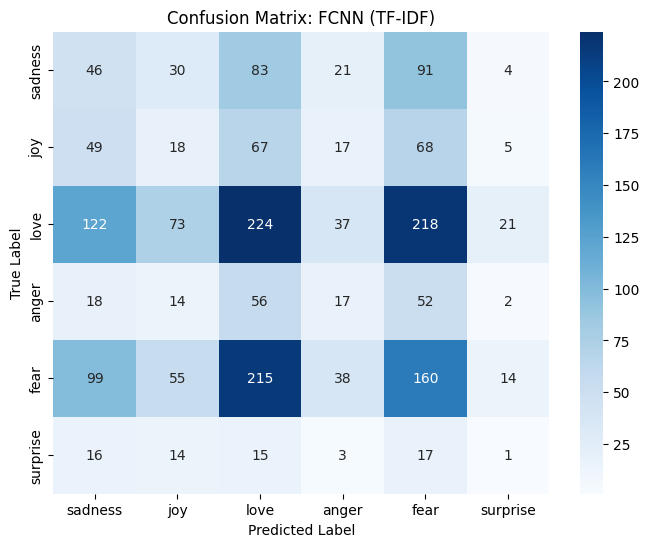

In [41]:
# confusion matrix for Fcnn
fcnn_probs = model_fcnn.predict(X_test_tfidf)
fcnn_preds = np.argmax(fcnn_probs, axis=1)
plot_emotion_cm(test_df['label_idx'], fcnn_preds, "FCNN (TF-IDF)")

In [21]:
print(X_train_tfidf.shape)
print(y_train.shape)

(8192, 5000)
(8192,)


### Preparing Sequences for Embeddings

In [23]:
# Preparing Sequences for Embeddings

vocab_size = 10000
max_length = 100
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['clean_text'])

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['clean_text']), maxlen=max_length)
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(val_df['clean_text']), maxlen=max_length)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_text']), maxlen=max_length)

print(f"Sample sequence: {X_train_seq[0]}")

Sample sequence: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    2   83 5171   17    6
 5172  623]


## 5. A Recurrent Neural Network, based on LSTM

In [25]:
model_rnn = models.Sequential([
    layers.Embedding(vocab_size, 100, input_length=max_length),

    # Bidirectional LSTM
    layers.Bidirectional(layers.LSTM(64, return_sequences=False)),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax') # 6 classes for our emotions
])

model_rnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Train the RNN
history_rnn = model_rnn.fit(
    X_train_seq, train_df['label_idx'],
    epochs=5,
    batch_size=64,
    validation_data=(X_val_seq, val_df['label_idx'])
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


160/160 ━━━━━━━━━━━━━━━━━━━━ 35s 197ms/step - accuracy: 0.3320 - loss: 1.6322 - val_accuracy: 0.5477 - val_loss: 1.3190
Epoch 2/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 31s 195ms/step - accuracy: 0.6491 - loss: 0.9919 - val_accuracy: 0.7711 - val_loss: 0.7163
Epoch 3/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 45s 219ms/step - accuracy: 0.8555 - loss: 0.4446 - val_accuracy: 0.8332 - val_loss: 0.5567
Epoch 4/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 32s 199ms/step - accuracy: 0.9272 - loss: 0.2301 - val_accuracy: 0.8613 - val_loss: 0.4868
Epoch 5/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 32s 199ms/step - accuracy: 0.9620 - loss: 0.1362 - val_accuracy: 0.8633 - val_loss: 0.5395


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step


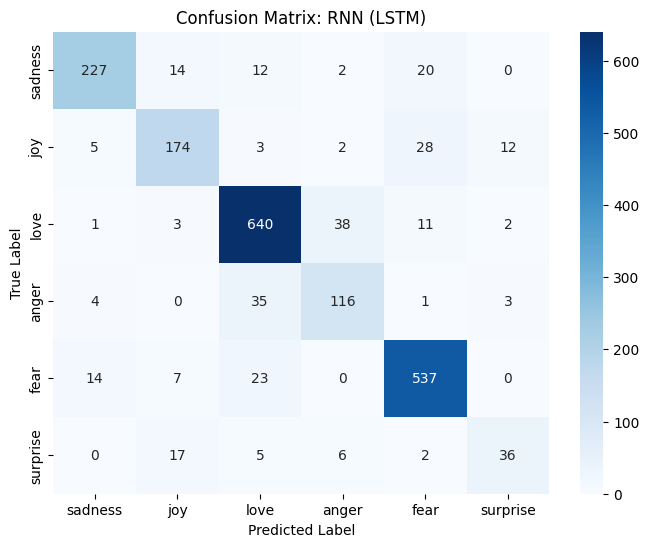

In [43]:
# confusion for RNN (LSTM)
rnn_probs = model_rnn.predict(X_test_seq)
rnn_preds = np.argmax(rnn_probs, axis=1)

plot_emotion_cm(test_df['label_idx'], rnn_preds, "RNN (LSTM)")

In [33]:
!pip install tf-keras

## 6. A fine-tuned Transformer Architecture from a pretrained model that can be found on sites like HuggingFace

In [34]:
# 1. Setup
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
transformer_model = TFAutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6,
    from_pt=True
)

# 2. Prepare Data
def tokenize_tweets(texts):
    return dict(tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="tf"
    ))

X_train_tf = tokenize_tweets(train_df['clean_text'])
X_val_tf = tokenize_tweets(val_df['clean_text'])

# 3. Compile using tf_keras
transformer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# 4. Train
history_transformer = transformer_model.fit(
    X_train_tf,
    train_df['label_idx'],
    validation_data=(X_val_tf, val_df['label_idx']),
    epochs=3,
    batch_size=16
)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_projector.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'cla

Epoch 1/3
640/640 [==============================] - 5108s 8s/step - loss: 0.4839 - accuracy: 0.8302 - val_loss: 0.2480 - val_accuracy: 0.9160
Epoch 2/3
640/640 [==============================] - 4697s 7s/step - loss: 0.1565 - accuracy: 0.9346 - val_loss: 0.1722 - val_accuracy: 0.9312
Epoch 3/3
640/640 [==============================] - 4717s 7s/step - loss: 0.1158 - accuracy: 0.9482 - val_loss: 0.1670 - val_accuracy: 0.9332


63/63 [==============================] - 180s 3s/step


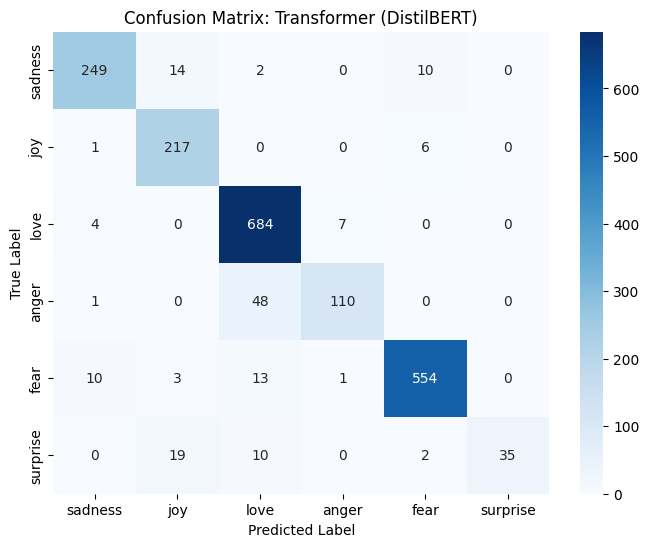

In [44]:
# confusion matrix for (DistilBERT) Transformer
# Tokenize test data first if you haven't
X_test_tf = tokenize_tweets(test_df['clean_text'])

# Get predictions
bert_output = transformer_model.predict(X_test_tf)
bert_preds = np.argmax(bert_output.logits, axis=1)

plot_emotion_cm(test_df['label_idx'], bert_preds, "Transformer (DistilBERT)")

## 7. Comparing the different Models

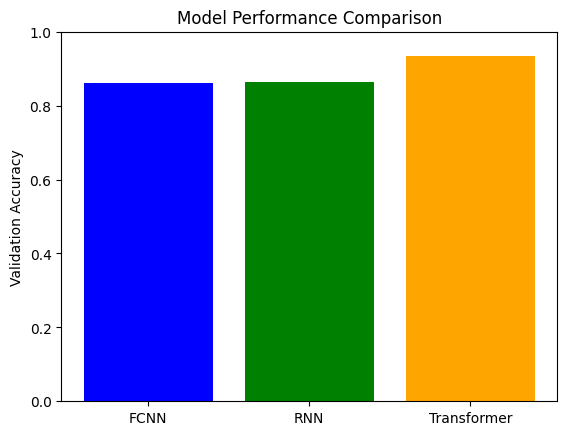

FCNN Accuracy: 0.8618
RNN Accuracy: 0.8633
Transformer Accuracy: 0.9332


In [38]:
# final validation accuracies
accuracies = {
    "FCNN": history.history['val_accuracy'][-1],
    "RNN": history_rnn.history['val_accuracy'][-1],
    "Transformer": history_transformer.history['val_accuracy'][-1]
}

# Plotting the comparison
plt.bar(accuracies.keys(), accuracies.values(), color=['blue', 'green', 'orange'])
plt.ylabel('Validation Accuracy')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.0)
plt.show()

for model, acc in accuracies.items():
    print(f"{model} Accuracy: {acc:.4f}")

## Best approach and what I have learned from this exercise

* FCNN Performance: Likely the lowest. It treats words as piles (Bag of Words) and loses the meaning of phrases like not happy

* RNN Performance: Better It reads the tweet like a human left to right which helps it understand sentiment flow.

* Transformer Performance: the best It uses Attention to see the whole tweet at once picking up on context clues that other models miss

* Future Use Cases: Mention that for a new task you would start with a Transformer because it handles complex language better and requires less custom preprocessing.

* The Best Approach: In most sentiment or emotion classification tasks the Transformer is the best approach. While FCNNs are efficient baselines they fail to distinguish between phrases like "not happy" and "happy not sad." RNNs improve on this but can struggle with long range dependencies. Transformers use "Attention" to look at every word simultaneously allowing them to grasp nuanced emotional cues more effectively.

* Contextual Importance: Language is more than just a collection of words the order and relationship between tokens which Transformers handle best are vital for detecting complex emotions.

* The Power of Pre-training: Fine-tuning a pre-trained model like DistilBERT is often more efficient and accurate than training a complex RNN from scratch because the model already understands English grammar.

## How would you proceed with another text classification use case

* Exploratory Data Analysis (EDA): Use data to get the counts or frequency plots to understand the distribution of labels.
* Immediate Baseline: Run a simple model (like TF-IDF + Logistic Regression or a small FCNN) to build a baseline quickly.
* Transformer-First Strategy: Instead of building custom RNNs, I would jump straight to Fine-tuning a Transformer (e:g BERT, RoBERTa, or DeBERTa) using Hugging Face as these provide the highest accuracy with minimal feature engineering.
